# Streaming Process Mining - End-to-End Pipeline

This notebook demonstrates the complete streaming process mining pipeline:
1. Load XES event log
2. Process events through sliding window and decay list
3. Prepare dataset for mining
4. Discover BPMN process model
5. Export results (XES and PNG)



In [ ]:
# Install dependencies
# !pip -q install pm4py pandas numpy matplotlib graphviz pydot xes tqdm pytest ruff mypy pydantic

In [27]:
import sys
import os
from pathlib import Path
from datetime import datetime, timedelta
from pytz import UTC

# Find project root: go up from notebooks/ directory
current_dir = Path.cwd()
if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    # Search for src/stream_mining/ directory
    project_root = current_dir
    for parent in [current_dir] + list(current_dir.parents):
        if (parent / "src" / "stream_mining").exists():
            project_root = parent
            break

# Convert to absolute path
project_root = project_root.resolve()
src_path = project_root / "src"

# Add src/ to sys.path (not src/stream_mining!)
# This allows: from stream_mining.io_xes import read_xes
src_path_str = str(src_path)
if src_path_str not in sys.path:
    sys.path.insert(0, src_path_str)

print(f"Project root: {project_root}")
print(f"Source path: {src_path}")
print(f"Added to sys.path: {src_path_str}")
print(f"sys.path[0]: {sys.path[0]}")

# Verify paths exist
if not src_path.exists():
    raise FileNotFoundError(f"Source directory not found: {src_path}")
if not (src_path / "stream_mining").exists():
    raise FileNotFoundError(f"stream_mining module not found in: {src_path}")

# Import stream mining modules
from stream_mining.io_xes import read_xes
from stream_mining.sliding_window import SlidingWindowCount
from stream_mining.decay_list import DecayList
from stream_mining.prepare_dataset import prepare_for_mining
from stream_mining.mining import discover_heuristics
from stream_mining.export import export_xes, export_bpmn_png

print("✓ Imports successful!")

Project root: C:\github\process-mining
Source path: C:\github\process-mining\src
Added to sys.path: C:\github\process-mining\src
sys.path[0]: C:\github\process-mining\src
✓ Imports successful!


## Data Loading

Load the sample XES file. If running in Colab, you may need to upload the file or use a different path.



In [28]:
data_dir = project_root / "data" / "in"
xes_file = data_dir / "sample_small.xes"

if not xes_file.exists():
    xes_file = Path("sample_small.xes")
    if not xes_file.exists():
        xes_file = Path("data") / "sample_small.xes"
        if not xes_file.exists():
            print("Warning: sample_small.xes not found. Please ensure the file exists.")
            print(f"Looking for: {xes_file}")

print(f"Loading XES file: {xes_file}")
log = read_xes(str(xes_file))

print(f"\nLoaded {len(log.traces)} traces")
total_events = sum(len(trace.events) for trace in log.traces)
print(f"Total events: {total_events}")

if log.traces:
    print(f"\nFirst trace (case_id: {log.traces[0].case_id}):")
    for event in log.traces[0].events:
        print(f"  - {event.activity} at {event.timestamp}")


Loading XES file: C:\github\process-mining\data\in\sample_small.xes


parsing log, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]


Loaded 3 traces
Total events: 9

First trace (case_id: case1):
  - start at 2024-01-01 10:00:00+00:00
  - process at 2024-01-01 10:05:00+00:00
  - end at 2024-01-01 10:10:00+00:00


## Streaming Simulation

Simulate streaming processing by iterating through events and feeding them to:
1. **Sliding Window**: Maintains a fixed-size window of recent events
2. **Decay List**: Maintains historical events with exponential decay weights



In [29]:
# Initialize sliding window and decay list
window_size = 50  # Keep last 50 events in window
half_life = timedelta(hours=24)  # Events decay with 24-hour half-life

window = SlidingWindowCount(max_events=window_size)
decay = DecayList(half_life=half_life)

# Process all events from the log
print("Processing events through sliding window and decay list...")
print("Events are added to decay list ONLY when evicted from window (when window is full).")
evicted_count = 0

now = datetime.now(UTC)

for trace in log.traces:
    for event in trace.events:
        # Push to sliding window (may evict oldest event when window is full)
        evicted = window.push(event)
        
        # Only add to decay list when window is full and event is evicted
        # This is the ONLY way events enter the decay list
        if evicted:
            decay.update(evicted)
            evicted_count += 1

print(f"\nProcessing complete!")
print(f"Window size: {len(window)} events")
print(f"Decay list size: {decay.stats()['size']} events")
print(f"Events evicted from window: {evicted_count}")

# Display window stats
window_stats = window.stats()
print(f"\nWindow stats:")
print(f"  - Size: {window_stats['size']}")
if window_stats.get('oldest_timestamp'):
    print(f"  - Oldest: {window_stats['oldest_timestamp']}")
    print(f"  - Newest: {window_stats['newest_timestamp']}")

# Display decay list stats
decay_stats = decay.stats(reference_time=now)
print(f"\nDecay list stats:")
print(f"  - Size: {decay_stats['size']}")
if decay_stats.get('min_weight') is not None:
    print(f"  - Min weight: {decay_stats['min_weight']:.4f}")
    print(f"  - Max weight: {decay_stats['max_weight']:.4f}")



Processing events through sliding window and decay list...
Events are added to decay list ONLY when evicted from window (when window is full).

Processing complete!
Window size: 9 events
Decay list size: 0 events
Events evicted from window: 0

Window stats:
  - Size: 9
  - Oldest: 2024-01-01 10:00:00+00:00
  - Newest: 2024-01-01 12:15:00+00:00

Decay list stats:
  - Size: 0


## Dataset Preparation

Prepare dataset for mining:
- **Sliding window** is the PRIMARY source (all events currently in window)
- **Decay list** is used to "revive" traces that are NOT in the window
  (when a new event arrives for a case that was previously evicted)



In [30]:
event_log = prepare_for_mining(window, decay, now)

print(f"Prepared EventLog:")
print(f"  - Traces: {len(event_log)}")
total_events = sum(len(trace) for trace in event_log)
print(f"  - Total events: {total_events}")

if len(event_log) > 0:
    print(f"\nFirst few traces:")
    for i, trace in enumerate(event_log[:3]):
        case_id = trace.attributes.get("concept:name", f"trace_{i}")
        print(f"  - {case_id}: {len(trace)} events")
        if len(trace) > 0:
            activities = [event["concept:name"] for event in trace]
            print(f"    Activities: {' -> '.join(activities)}")



Prepared EventLog:
  - Traces: 3
  - Total events: 9

First few traces:
  - case1: 3 events
    Activities: start -> process -> end
  - case2: 2 events
    Activities: start -> end
  - case3: 4 events
    Activities: start -> process -> review -> end


## Process Mining

Discover BPMN process model using Inductive Miner algorithm.



In [31]:
print("Discovering BPMN process model using Heuristics Miner...")

try:
    # Use Heuristics Miner as required by the plan
    # Lower dependency_thresh includes more dependencies (simpler model)
    # Higher dependency_thresh requires stronger dependencies (more selective)
    bpmn_model = discover_heuristics(
        event_log, 
        dependency_thresh=0.5  # Lower threshold for simpler model with fewer gateways
    )
    
    print(f"event log: {event_log}")
    
    if bpmn_model is not None:
        print("✓ BPMN model discovered successfully using Heuristics Miner!")
        print(f"  Model type: {type(bpmn_model).__name__}")
    else:
        print("⚠ Model discovery returned None")
        
except ValueError as e:
    print(f"✗ Model discovery failed: {e}")
    print("This may happen if there are insufficient events or traces.")
    bpmn_model = None



Discovering BPMN process model using Heuristics Miner...
event log: [{'attributes': {'concept:name': 'case1'}, 'events': [{'concept:name': 'start', 'time:timestamp': Timestamp('2024-01-01 10:00:00+0000', tz='UTC'), 'org:resource': 'user1'}, '..', {'concept:name': 'end', 'time:timestamp': Timestamp('2024-01-01 10:10:00+0000', tz='UTC')}]}, '....', {'attributes': {'concept:name': 'case3'}, 'events': [{'concept:name': 'start', 'time:timestamp': Timestamp('2024-01-01 12:00:00+0000', tz='UTC')}, '..', {'concept:name': 'end', 'time:timestamp': Timestamp('2024-01-01 12:15:00+0000', tz='UTC')}]}]
✓ BPMN model discovered successfully using Heuristics Miner!
  Model type: BPMN


## Export Results

Export the processed event log and discovered model to files.



In [32]:
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

from stream_mining.io_xes import Log, Trace

window_log = Log(traces=[])
case_events = {}

for event in window.iter_events():
    if event.case_id not in case_events:
        case_events[event.case_id] = []
    case_events[event.case_id].append(event)

for case_id, events in case_events.items():
    trace = Trace(case_id=case_id, events=sorted(events, key=lambda e: e.timestamp))
    window_log.traces.append(trace)

xes_output = results_dir / "stream_snapshot.xes"
export_xes(window_log, str(xes_output))
print(f"✓ Exported XES snapshot: {xes_output}")

if bpmn_model is not None:
    png_output = results_dir / "model_bpmn.png"
    export_bpmn_png(bpmn_model, str(png_output))
    print(f"✓ Exported BPMN model: {png_output}")
else:
    print("⚠ Skipping PNG export (no model discovered)")



exporting log, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

✓ Exported XES snapshot: C:\github\process-mining\results\stream_snapshot.xes
✓ Exported BPMN model: C:\github\process-mining\results\model_bpmn.png


## Validation & Visualization

Display statistics and visualize the discovered model.



In [33]:
print("=" * 60)
print("PIPELINE SUMMARY")
print("=" * 60)

print(f"\n📊 Input Data:")
print(f"  - Original traces: {len(log.traces)}")
original_events = sum(len(trace.events) for trace in log.traces)
print(f"  - Original events: {original_events}")

print(f"\n🪟 Sliding Window:")
print(f"  - Current size: {len(window)} / {window.max_events}")
window_stats = window.stats()
if window_stats.get('oldest_timestamp'):
    window_span = window_stats['newest_timestamp'] - window_stats['oldest_timestamp']
    print(f"  - Time span: {window_span}")

print(f"\n📉 Decay List:")
decay_stats = decay.stats(reference_time=now)
print(f"  - Total events: {decay_stats['size']}")
if decay_stats.get('min_weight') is not None:
    print(f"  - Weight range: {decay_stats['min_weight']:.4f} - {decay_stats['max_weight']:.4f}")

print(f"\n🔧 Prepared Dataset:")
print(f"  - Traces for mining: {len(event_log)}")
mining_events = sum(len(trace) for trace in event_log)
print(f"  - Events for mining: {mining_events}")

print(f"\n🎯 Process Model:")
if bpmn_model is not None:
    print(f"  - Status: ✓ Discovered")
    print(f"  - Type: BPMN")
else:
    print(f"  - Status: ✗ Not discovered")

print(f"\n💾 Output Files:")
print(f"  - XES snapshot: {xes_output}")
if bpmn_model is not None:
    print(f"  - BPMN PNG: {png_output}")

print("\n" + "=" * 60)



PIPELINE SUMMARY

📊 Input Data:
  - Original traces: 3
  - Original events: 9

🪟 Sliding Window:
  - Current size: 9 / 50
  - Time span: 0 days 02:15:00

📉 Decay List:
  - Total events: 0

🔧 Prepared Dataset:
  - Traces for mining: 3
  - Events for mining: 9

🎯 Process Model:
  - Status: ✓ Discovered
  - Type: BPMN

💾 Output Files:
  - XES snapshot: C:\github\process-mining\results\stream_snapshot.xes
  - BPMN PNG: C:\github\process-mining\results\model_bpmn.png



Discovered BPMN Process Model:


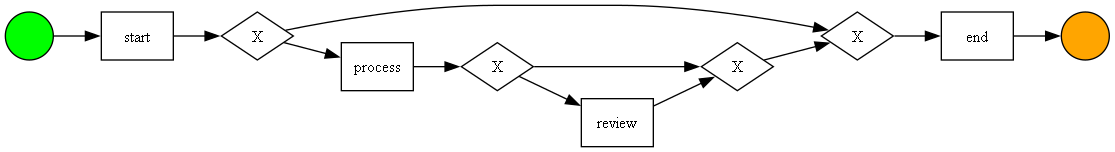

In [34]:
from IPython.display import Image, display

if bpmn_model is not None:
    png_path = results_dir / "model_bpmn.png"
    if png_path.exists():
        print("Discovered BPMN Process Model:")
        display(Image(str(png_path)))
    else:
        print("⚠ PNG file not found. Model may not have been exported successfully.")
else:
    print("⚠ No model to display (discovery failed or returned None)")

